# Universal EDA Boilerplate — understand any dataframe in minutes

**One dataset or many:** set `DF` (in-memory) or `DATA_PATH` (file/URL) for your own data, or set `SAMPLE` to one name — or a *list* of names — to tour the vendored `data/*.csv` offline. Default runs three datasets (`mpg`, `penguins`, `sunspots`) so this committed file shows baked outputs for regression, classification, and time-aware data in a single Run All.

**Rule of this notebook:** every code cell does exactly *one* task. Read the `→` lines out loud — they are the interview narration.

Outputs below are baked in (executed 2026-10-07). Re-run any cell after changing Cell 2.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

try:
    import plotly.express as px
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False
    print("plotly not available — heatmap/trend fall back to matplotlib.")

print("pandas", pd.__version__, "| plotly:", HAS_PLOTLY)

pandas 3.0.5 | plotly: True


## 1 — Configuration (the ONLY cell you edit)

In [2]:
# ---- Flexible input: DF > DATA_PATH > SAMPLE > synthetic fallback ----
DF = None                  # e.g. DF = my_df  (in-memory takes precedence)
DATA_PATH = None           # e.g. "data/mpg.csv" or "https://.../file.csv" (.csv/.parquet)
SAMPLE = ["mpg", "penguins", "sunspots"]  # one name, a list, or None
TARGET_COL = "mpg"          # used for DF / DATA_PATH / single SAMPLE; lists use per-sample defaults below
DATE_COL = None             # datetime col, or None for auto-detect
ID_COLS = []                # e.g. ["id", "name"]

SAMPLE_FILES = {
    "mpg": ("data/mpg.csv", "mpg"),
    "penguins": ("data/penguins.csv", "species"),
    "iris": ("data/iris.csv", None),
    "diamonds": ("data/diamonds.csv", "price"),
    "births": ("data/daily-female-births.csv", "Births"),
    "sunspots": ("data/monthly-sunspots.csv", "Sunspots"),
}
RANDOM_STATE = 42

## 2 — Loader
One task: build the `DATASETS` dict (`name -> {df, target, date}`). Every later cell loops over it.

In [3]:
def load_table(path):
    p = str(path)
    is_url = p.startswith(("http://", "https://"))
    ext = p.split("?")[0].lower().rsplit(".", 1)[-1] if "." in p.split("?")[0] else ""
    if ext == "parquet":
        assert not is_url, "parquet-over-URL needs fsspec — download it locally first"
        return pd.read_parquet(p)
    return pd.read_csv(p)

def repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data" / "mpg.csv").exists():
            return p
    return Path(".")

def synth_demo():
    rng = np.random.default_rng(RANDOM_STATE)
    n = 1000
    dd = pd.DataFrame({
        "num_a": rng.normal(0, 1, n),
        "num_b": rng.exponential(1.0, n),
        "cat_c": rng.choice(["a", "b", "c", None], n, p=[.4, .3, .2, .1]),
        "date": pd.date_range("2024-01-01", periods=n, freq="D"),
    })
    dd["target"] = ((dd["num_a"] + rng.normal(0, .5, n)) > 0).astype(int)
    dd.loc[rng.choice(n, 50, replace=False), "num_b"] = np.nan
    return dd

DATASETS = {}
root = repo_root()
if DF is not None:
    DATASETS["custom"] = {"df": DF.copy(), "target": TARGET_COL, "date": DATE_COL}
elif DATA_PATH:
    DATASETS["custom"] = {"df": load_table(DATA_PATH), "target": TARGET_COL, "date": DATE_COL}
else:
    names = SAMPLE if isinstance(SAMPLE, list) else [SAMPLE]
    for s in names:
        if s in SAMPLE_FILES:
            rel, default_tgt = SAMPLE_FILES[s]
            try:
                DATASETS[s] = {"df": load_table(str(root / rel)),
                               "target": default_tgt if len(names) > 1 else TARGET_COL,
                               "date": DATE_COL}
            except FileNotFoundError:
                print(f"{s}: file missing, skipped")
if not DATASETS:
    print("no data found — synthetic fallback")
    DATASETS["synthetic"] = {"df": synth_demo(), "target": "target", "date": "date"}

for _n, _D in DATASETS.items():
    _d, _t = _D["df"], _D["target"]
    if _t is not None and _t not in _d.columns:
        print(f"{_n}: target '{_t}' missing — profile-only for this dataset")
        _D["target"] = None
    if _D["date"] is not None and _D["date"] not in _d.columns:
        _D["date"] = None
print("datasets:", {n: (D["df"].shape, D["target"], D["date"]) for n, D in DATASETS.items()})

datasets: {'mpg': ((398, 9), 'mpg', None), 'penguins': ((344, 7), 'species', None), 'sunspots': ((2820, 2), 'Sunspots', None)}


## 3 — First look
One task: `head()` of each dataset.

In [4]:
for name, D in DATASETS.items():
    print(f"===== {name} {D['df'].shape} =====")
    display(D["df"].head(3))

===== mpg (398, 9) =====


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite


===== penguins (344, 7) =====


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE


===== sunspots (2820, 2) =====


,Month,Sunspots
0,1749-01,58.0
1,1749-02,62.6
2,1749-03,70.0


## 4 — Shape & memory
One task: rows, columns, memory per dataset.

In [5]:
rows = [{"dataset": n, "rows": len(D["df"]), "cols": D["df"].shape[1],
             "memory_MB": round(D["df"].memory_usage(deep=True).sum() / 1e6, 2)} for n, D in DATASETS.items()]
display(pd.DataFrame(rows).set_index("dataset"))
print("→ Say rows/cols/memory before anything else.")

,rows,cols,memory_MB
dataset,,,
mpg,398,9,0.04
penguins,344,7,0.03
sunspots,2820,2,0.06


→ Say rows/cols/memory before anything else.


## 5 — Duplicates
One task: duplicated-row counts.

In [6]:
for name, D in DATASETS.items():
    df = D["df"]
    print(f"{name}: {df.duplicated().sum():,} dups ({df.duplicated().mean():.2%})")
print("→ >1% dups? ask 'same event logged twice, or a join fan-out?'")

mpg: 0 dups (0.00%)
penguins: 0 dups (0.00%)
sunspots: 0 dups (0.00%)
→ >1% dups? ask 'same event logged twice, or a join fan-out?'


## 6 — Column profile
One task: dtype / missing / uniqueness table per dataset.

In [7]:
for name, D in DATASETS.items():
    df = D["df"]
    prof = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=False),
    })
    print(f"===== {name} =====")
    display(prof)

===== mpg =====


,dtype,pct_missing,n_unique
mpg,float64,0.00,129
cylinders,int64,0.00,5
displacement,float64,0.00,82
horsepower,float64,1.51,94
weight,int64,0.00,351
acceleration,float64,0.00,95
model_year,int64,0.00,13
origin,str,0.00,3
name,str,0.00,305


===== penguins =====


,dtype,pct_missing,n_unique
species,str,0.00,3
island,str,0.00,3
bill_length_mm,float64,0.58,165
bill_depth_mm,float64,0.58,81
flipper_length_mm,float64,0.58,56
body_mass_g,float64,0.58,95
sex,str,3.20,3


===== sunspots =====


,dtype,pct_missing,n_unique
Month,str,0.0,2820
Sunspots,float64,0.0,1140


## 7 — Constants & ID-like columns
One task: flag drop-from-features columns.

In [8]:
for name, D in DATASETS.items():
    df = D["df"]
    const = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    idlike = [c for c in df.columns if df[c].nunique(dropna=False) == len(df)]
    extra = [c for c in ID_COLS if c in df.columns]
    print(f"{name}: constant={const or '—'} | id-like={list(dict.fromkeys(idlike + extra)) or '—'}")
print("→ Say: constants carry zero signal; ID-like cols must be dropped from features.")

mpg: constant=— | id-like=—
penguins: constant=— | id-like=—
sunspots: constant=— | id-like=['Month']
→ Say: constants carry zero signal; ID-like cols must be dropped from features.


## 8 — Missingness counts
One task: which columns are missing, how much.

In [9]:
for name, D in DATASETS.items():
    miss = D["df"].isna().mean()
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"===== {name}: {len(miss)} cols with missing =====")
    if len(miss):
        display(pd.DataFrame({"pct_missing": (miss * 100).round(2)})) 
    else:
        print("no missing values")

===== mpg: 1 cols with missing =====


,pct_missing
horsepower,1.51


===== penguins: 5 cols with missing =====


,pct_missing
sex,3.20
bill_length_mm,0.58
bill_depth_mm,0.58
flipper_length_mm,0.58
body_mass_g,0.58


===== sunspots: 0 cols with missing =====
no missing values


## 9 — Missingness chart
One task: bar chart of missingness (matplotlib).

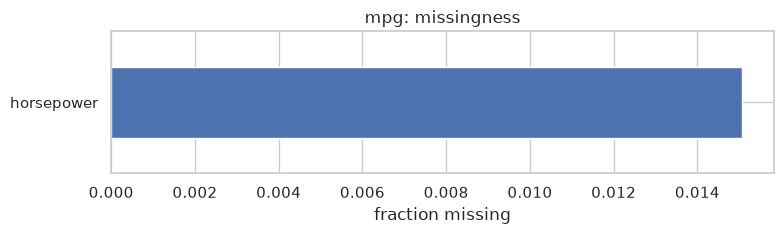

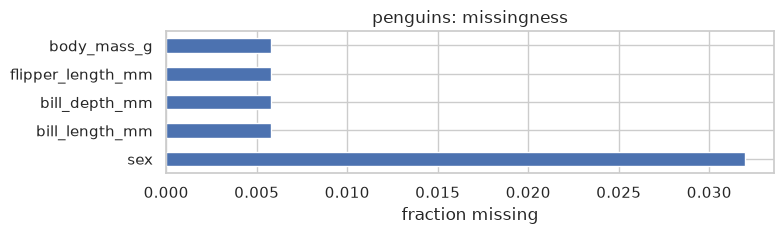

In [10]:
for name, D in DATASETS.items():
    miss = D["df"].isna().mean()
    miss = miss[miss > 0].sort_values(ascending=False)
    if len(miss):
        plt.figure(figsize=(8, max(2.5, .45 * len(miss))))
        miss.plot(kind="barh")
        plt.xlabel("fraction missing"); plt.title(f"{name}: missingness")
        plt.tight_layout(); plt.show()

## 10 — Is missingness predictive?
One task: target rate when a column is missing vs present (MNAR check).

In [11]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    miss = df.isna().mean()
    miss = miss[miss > 0].sort_values(ascending=False)
    if TGT in df.columns and len(miss):
        y = df[TGT]
        print(f"===== {name} (target={TGT}) =====")
        for c in miss.index[:3]:
            m = df[c].isna()
            if pd.api.types.is_numeric_dtype(y):
                print(f"  {c}: mean(target|missing)={y[m].mean():.3f} vs present={y[~m].mean():.3f}")
            else:
                print(f"  {c}: share of top class when missing vs present differs?", 
                      y[m].value_counts(normalize=True).head(1).round(3).to_dict(),
                      y[~m].value_counts(normalize=True).head(1).round(3).to_dict())
print("→ Big gaps = INFORMATIVE missingness: keep a missing-indicator, don't just impute.")

===== mpg (target=mpg) =====
  horsepower: mean(target|missing)=28.000 vs present=23.446
===== penguins (target=species) =====
  sex: share of top class when missing vs present differs? {'Adelie': 0.545} {'Adelie': 0.438}
  bill_length_mm: share of top class when missing vs present differs? {'Adelie': 0.5} {'Adelie': 0.442}
  bill_depth_mm: share of top class when missing vs present differs? {'Adelie': 0.5} {'Adelie': 0.442}
→ Big gaps = INFORMATIVE missingness: keep a missing-indicator, don't just impute.


## 11 — Numeric describe
One task: describe + skew/kurt per dataset.

In [12]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    nums = [c for c in df.select_dtypes(include="number").columns if c != TGT]
    print(f"===== {name}: {len(nums)} numeric feature cols =====")
    if nums:
        desc = df[nums].describe().T
        desc["skew"] = df[nums].skew()
        desc["kurt"] = df[nums].kurt()
        display(desc.round(3))

===== mpg: 6 numeric feature cols =====


,count,mean,std,min,25%,50%,75%,max,skew,kurt
cylinders,398.0,5.455,1.701,3.0,4.000,4.0,8.000,8.0,0.527,-1.377
displacement,398.0,193.426,104.270,68.0,104.250,148.5,262.000,455.0,0.720,-0.747
horsepower,392.0,104.469,38.491,46.0,75.000,93.5,126.000,230.0,1.087,0.697
weight,398.0,2970.425,846.842,1613.0,2223.750,2803.5,3608.000,5140.0,0.531,-0.786
acceleration,398.0,15.568,2.758,8.0,13.825,15.5,17.175,24.8,0.279,0.419
model_year,398.0,76.010,3.698,70.0,73.000,76.0,79.000,82.0,0.012,-1.181


===== penguins: 4 numeric feature cols =====


,count,mean,std,min,25%,50%,75%,max,skew,kurt
bill_length_mm,342.0,43.922,5.460,32.1,39.225,44.45,48.5,59.6,0.053,-0.876
bill_depth_mm,342.0,17.151,1.975,13.1,15.600,17.30,18.7,21.5,-0.143,-0.907
flipper_length_mm,342.0,200.915,14.062,172.0,190.000,197.00,213.0,231.0,0.346,-0.984
body_mass_g,342.0,4201.754,801.955,2700.0,3550.000,4050.00,4750.0,6300.0,0.470,-0.719


===== sunspots: 0 numeric feature cols =====


## 12 — Numeric histograms
One task: distribution shape (first 4 numerics each).

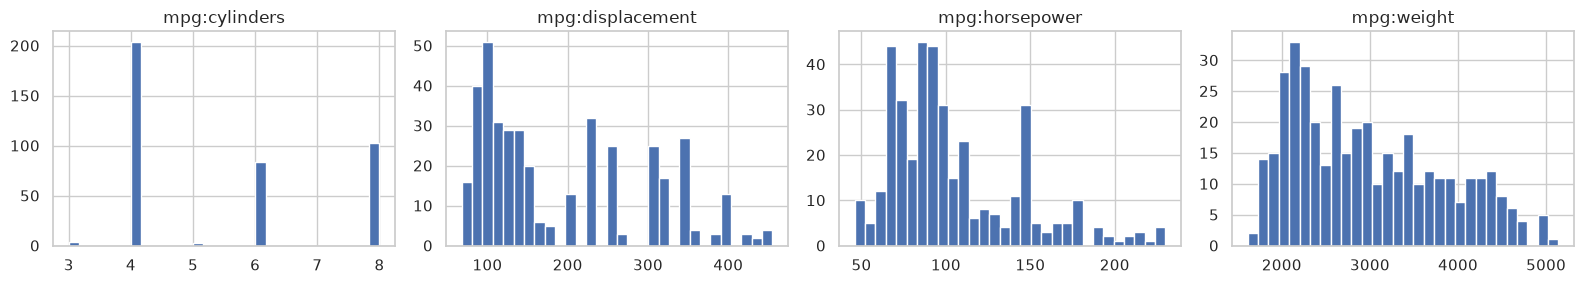

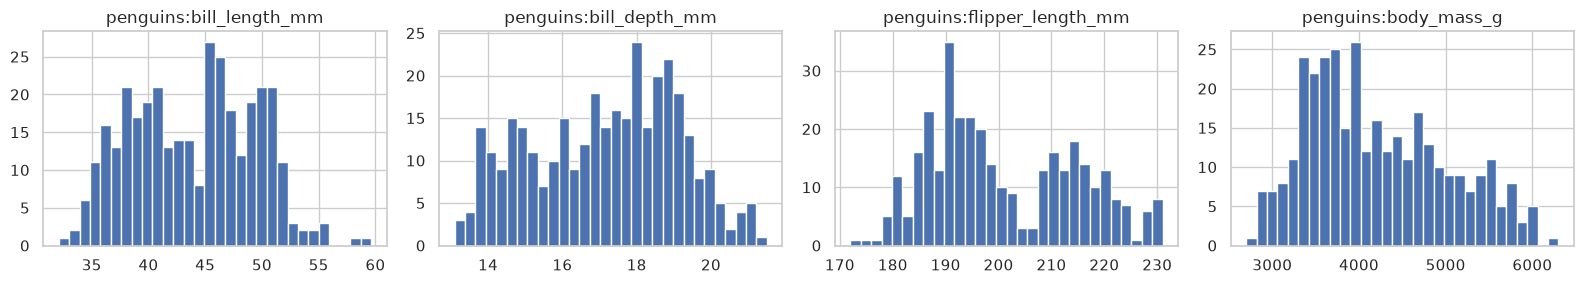

In [13]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    nums = [c for c in df.select_dtypes(include="number").columns if c != TGT][:4]
    if nums:
        fig, axes = plt.subplots(1, len(nums), figsize=(4 * len(nums), 3))
        for ax, c in zip(np.atleast_1d(axes), nums):
            ax.hist(df[c].dropna(), bins=30); ax.set_title(f"{name}:{c}")
        plt.tight_layout(); plt.show()

## 13 — Numeric boxplots
One task: spread/outlier eyeball test.

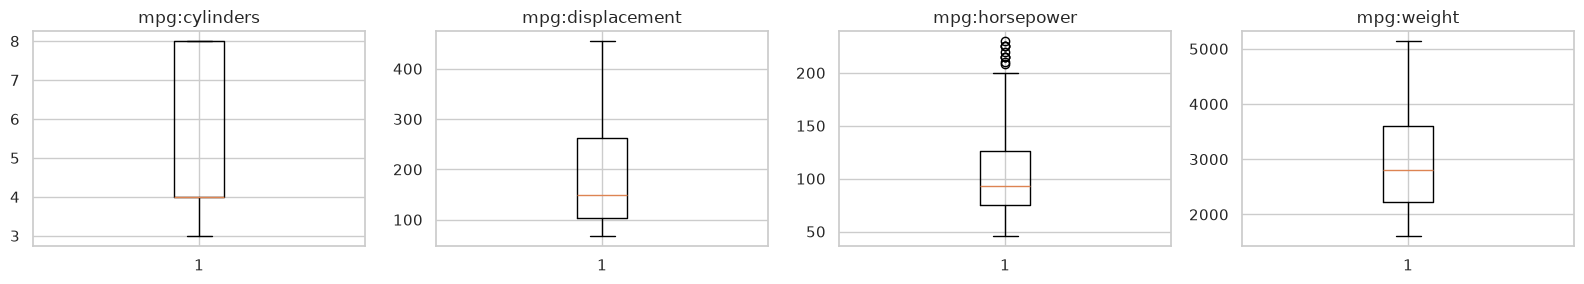

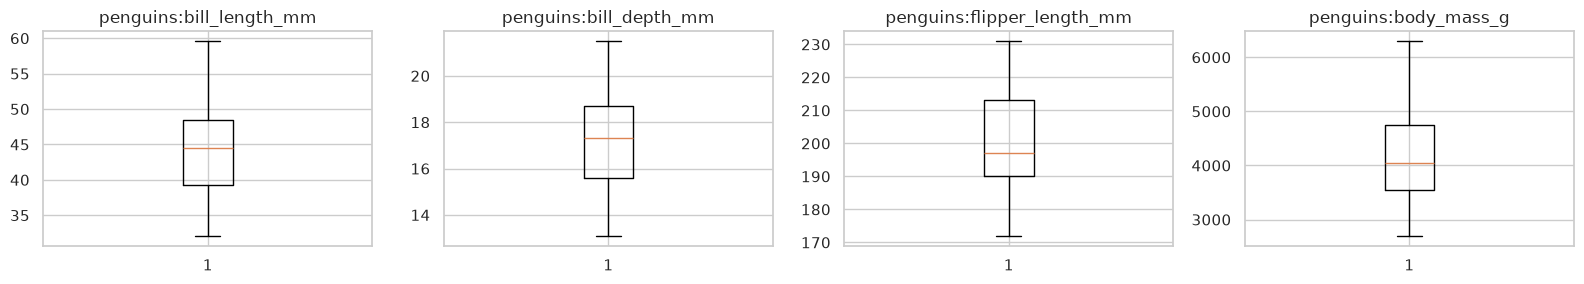

In [14]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    nums = [c for c in df.select_dtypes(include="number").columns if c != TGT][:4]
    if nums:
        fig, axes = plt.subplots(1, len(nums), figsize=(4 * len(nums), 3))
        for ax, c in zip(np.atleast_1d(axes), nums):
            ax.boxplot(df[c].dropna(), vert=True); ax.set_title(f"{name}:{c}")
        plt.tight_layout(); plt.show()

## 14 — Outlier scan (IQR rule)
One task: share of points beyond 1.5×IQR.

In [15]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    out = {}
    for c in [c for c in df.select_dtypes(include="number").columns if c != TGT]:
        s = df[c].dropna()
        q1, q3 = s.quantile(.25), s.quantile(.75)
        iqr = q3 - q1
        if iqr > 0:
            out[c] = round(float(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean()), 4)
    print(f"{name}: {out or 'no numeric cols'}")
print("→ >1–2%? 'entry error vs heavy tail → robust scaler / tree model'.")

mpg: {'cylinders': 0.0, 'displacement': 0.0, 'horsepower': 0.0255, 'weight': 0.0, 'acceleration': 0.0176, 'model_year': 0.0}
penguins: {'bill_length_mm': 0.0, 'bill_depth_mm': 0.0, 'flipper_length_mm': 0.0, 'body_mass_g': 0.0}
sunspots: no numeric cols
→ >1–2%? 'entry error vs heavy tail → robust scaler / tree model'.


## 15 — Zero share
One task: how much of each numeric is exactly zero.

In [16]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    nums = [c for c in df.select_dtypes(include="number").columns if c != TGT]
    if nums:
        z = ((df[nums] == 0).mean() * 100).round(2).sort_values(ascending=False)
        print(f"{name} zeros %:")
        print(z.to_string())
print("→ Many zeros? zero-inflation; MAPE undefined at 0 — prefer sMAPE/MAE.")

mpg zeros %:
cylinders       0.0
displacement    0.0
horsepower      0.0
weight          0.0
acceleration    0.0
model_year      0.0
penguins zeros %:
bill_length_mm       0.0
bill_depth_mm        0.0
flipper_length_mm    0.0
body_mass_g          0.0
→ Many zeros? zero-inflation; MAPE undefined at 0 — prefer sMAPE/MAE.


## 16 — Categorical cardinality
One task: unique counts (low-card numerics counted as codes).

In [17]:
def cat_cols_of(df, tgt):
    cats = [c for c in df.select_dtypes(include=["object", "category", "bool"]).columns if c != tgt]
    for c in df.select_dtypes(include="number").columns:
        if c != tgt and df[c].nunique(dropna=True) <= 10 and c not in cats:
            cats.append(c)
    return cats

for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    print(f"{name}: {[(c, int(df[c].nunique(dropna=False))) for c in cat_cols_of(df, TGT)] or 'no categoricals'}")

mpg: [('origin', 3), ('name', 305), ('cylinders', 5)]
penguins: [('island', 3), ('sex', 3)]
sunspots: [('Month', 2820)]


## 17 — Categorical top values
One task: top-5 shares per categorical.

In [18]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    for c in cat_cols_of(df, TGT)[:6]:
        print(f"--- {name}:{c} ({df[c].nunique(dropna=False)} unique) ---")
        print((df[c].value_counts(dropna=False).head(5) / len(df)).round(4).to_string())

--- mpg:origin (3 unique) ---
origin
usa       0.6256
japan     0.1985
europe    0.1759
--- mpg:name (305 unique) ---
name
ford pinto          0.0151
ford maverick       0.0126
amc matador         0.0126
toyota corolla      0.0126
chevrolet impala    0.0101
--- mpg:cylinders (5 unique) ---
cylinders
4    0.5126
8    0.2588
6    0.2111
3    0.0101
5    0.0075
--- penguins:island (3 unique) ---
island
Biscoe       0.4884
Dream        0.3605
Torgersen    0.1512
--- penguins:sex (3 unique) ---
sex
MALE      0.4884
FEMALE    0.4797
NaN       0.0320
--- sunspots:Month (2820 unique) ---
Month
1749-01    0.0004
1749-02    0.0004
1749-03    0.0004
1749-04    0.0004
1749-05    0.0004


## 18 — Rare levels & high cardinality
One task: encoding warnings.

In [19]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    for c in cat_cols_of(df, TGT):
        nu = df[c].nunique(dropna=False)
        rare = int((df[c].value_counts(normalize=True, dropna=False) < 0.01).sum())
        if nu == len(df):
            print(f"{name}:{c} unique-per-row → ID-like, drop")
        elif nu > 50:
            print(f"{name}:{c} high-card ({nu}) → target/frequency encoding, not one-hot")
        elif rare:
            print(f"{name}:{c} {rare} rare level(s) <1% → group into 'Other'")
print("→ Say the encoding plan: one-hot vs target/frequency vs drop.")

mpg:name high-card (305) → target/frequency encoding, not one-hot
mpg:cylinders 1 rare level(s) <1% → group into 'Other'
sunspots:Month unique-per-row → ID-like, drop
→ Say the encoding plan: one-hot vs target/frequency vs drop.


## 19 — Datetime detection
One task: find datetime columns, report range/gaps/frequency.

In [20]:
def detect_dt(df, forced):
    if forced and forced in df.columns:
        return [forced]
    cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    for c in df.select_dtypes(include="object").columns:
        try:
            s = pd.to_datetime(df[c].dropna().head(200), errors="coerce")
            if len(s.dropna()) / max(len(df[c].dropna().head(200)), 1) > 0.9 and c not in cols:
                cols.append(c)
        except Exception:
            pass
    return cols

for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    dts = detect_dt(df, DTCOL)
    D["defacto_date"] = dts[0] if dts else None
    print(f"{name}: datetime cols = {dts or '—'}")
    if dts:
        t = pd.to_datetime(df[dts[0]], errors="coerce")
        dd = pd.DataFrame({"t": t}).dropna().sort_values("t")
        gaps = dd["t"].diff().dropna()
        print(f"  range {t.min()} → {t.max()} | NaT {int(t.isna().sum())} | median gap {gaps.median()} | max gap {gaps.max()} | freq {pd.infer_freq(dd['t'].head(50))}")
print("→ Say coverage, gaps, granularity; time present ⇒ split chronologically.")

mpg: datetime cols = —
penguins: datetime cols = —
sunspots: datetime cols = ['Month']
  range 1749-01-01 00:00:00 → 1983-12-01 00:00:00 | NaT 0 | median gap 31 days 00:00:00 | max gap 31 days 00:00:00 | freq MS
→ Say coverage, gaps, granularity; time present ⇒ split chronologically.


## 20 — Volume over time
One task: row-count trend (plotly if available).

In [21]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    dc = D.get("defacto_date")
    if not dc:
        continue
    t = pd.to_datetime(df[dc], errors="coerce")
    dd = pd.DataFrame({"t": t}).dropna().sort_values("t")
    rule = "ME" if dd["t"].diff().dropna().median() >= pd.Timedelta(days=20) else "D"
    trend = dd.set_index("t").assign(n=1)["n"].resample(rule).sum()
    if HAS_PLOTLY:
        px.line(x=trend.index, y=trend.values, title=f"{name}: row volume ({rule})").show()
    else:
        plt.figure(); plt.plot(trend.index, trend.values); plt.title(f"{name}: row volume ({rule})")
        plt.tight_layout(); plt.show()

## 21 — Task detection
One task: classify each target as classification / regression / +time.

In [22]:
def detect_task(y, has_time):
    nuniq = y.nunique(dropna=True)
    if pd.api.types.is_bool_dtype(y) or pd.api.types.is_object_dtype(y) or isinstance(y.dtype, pd.CategoricalDtype) or nuniq <= 20:
        t = "classification"
    else:
        t = "regression"
    return t + "+time" if has_time else t

for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    if TGT not in df.columns:
        D["task"] = None
        print(f"{name}: profile-only (no target)")
    else:
        D["task"] = detect_task(df[TGT], bool(D.get("defacto_date")))
        print(f"{name}: TASK={D['task']} (target '{TGT}', {df[TGT].nunique(dropna=True)} unique, {int(df[TGT].isna().sum())} missing)")

mpg: TASK=regression (target 'mpg', 129 unique, 0 missing)
penguins: TASK=classification (target 'species', 3 unique, 0 missing)
sunspots: TASK=regression+time (target 'Sunspots', 1140 unique, 0 missing)


## 22 — Target distribution chart
One task: bar (classification) or histogram (regression).

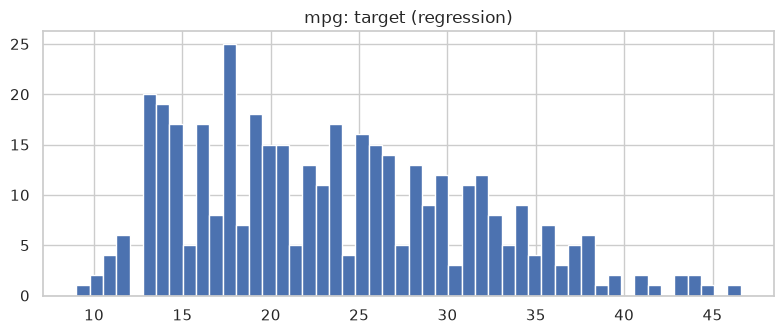

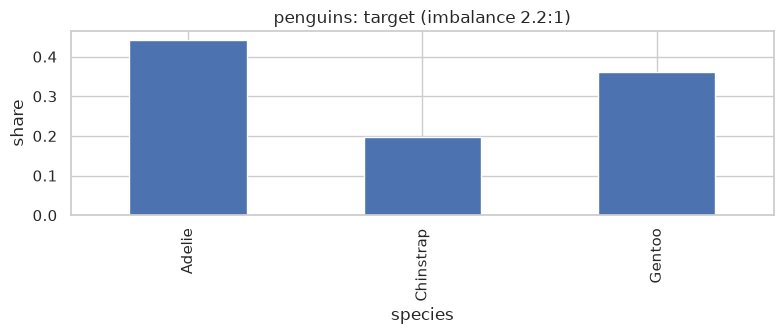

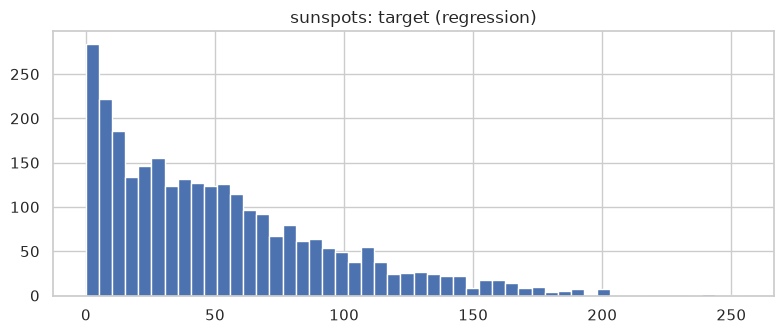

In [23]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    if not TGT or D.get("task") is None:
        continue
    y = df[TGT]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    if D["task"].startswith("classification"):
        vc = y.value_counts(dropna=False, normalize=True).sort_index()
        vc.plot(kind="bar", ax=ax); ax.set_ylabel("share")
        ax.set_title(f"{name}: target (imbalance {vc.max() / max(vc.min(), 1e-9):.1f}:1)")
        plt.tight_layout(); plt.show()
    else:
        ax.hist(pd.to_numeric(y, errors="coerce").dropna(), bins=50)
        ax.set_title(f"{name}: target (regression)"); plt.tight_layout(); plt.show()

## 23 — Target stats line
One task: balance / skew / zeros + what to say.

In [24]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    if not TGT or D.get("task") is None:
        continue
    y = df[TGT]
    if D["task"].startswith("classification"):
        vc = y.value_counts(dropna=False, normalize=True).round(4)
        print(f"{name} class share:", vc.to_dict())
        if vc.min() < 0.10:
            print("  → MINORITY <10%: stratify, report PR/F1 — not accuracy.")
    else:
        yn = pd.to_numeric(y, errors="coerce")
        print(f"{name}: skew={yn.skew():.2f} kurt={yn.kurt():.2f} zeros={(yn == 0).mean():.2%}")
        if abs(yn.skew()) > 1:
            print("  → |skew|>1: mention log-transform.")
        if (yn == 0).mean() > 0.05:
            print("  → >5% zeros: prefer sMAPE/MAE over MAPE.")

mpg: skew=0.46 kurt=-0.51 zeros=0.00%
penguins class share: {'Adelie': 0.4419, 'Gentoo': 0.3605, 'Chinstrap': 0.1977}
sunspots: skew=1.10 kurt=0.98 zeros=2.38%
  → |skew|>1: mention log-transform.


## 24 — Target correlations
One task: rank numerics by |corr| with the target.

In [25]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    nums = [c for c in df.select_dtypes(include="number").columns if c != TGT]
    if TGT in df.columns and nums:
        tmp = df[nums + [TGT]].copy()
        if D.get("task", "").startswith("classification"):
            tmp[TGT] = pd.factorize(tmp[TGT])[0]
        tmp[TGT] = pd.to_numeric(tmp[TGT], errors="coerce")
        ct = tmp.corr(numeric_only=True)[TGT].drop(TGT, errors="ignore").sort_values(key=abs, ascending=False)
        print(f"===== {name}: top |corr| with target =====")
        print(ct.head(8).round(3).to_string())
        D["corr_top"] = ct

===== mpg: top |corr| with target =====
weight         -0.832
displacement   -0.804
horsepower     -0.778
cylinders      -0.775
model_year      0.579
acceleration    0.420
===== penguins: top |corr| with target =====
flipper_length_mm    0.854
body_mass_g          0.750
bill_depth_mm       -0.744
bill_length_mm       0.731


## 25 — Leakage suspects
One task: flag |r|>0.9 (computed-after-outcome?) + multicollinear pairs.

In [26]:
for name, D in DATASETS.items():
    ct = D.get("corr_top")
    if ct is not None:
        sus = ct[ct.abs() > 0.9].index.tolist()
        D["leak"] = sus
        print(f"{name}: leakage suspects (|r|>0.9) = {sus or '—'}")
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    nums = [c for c in df.select_dtypes(include="number").columns if c != TGT][:12]
    pairs = []
    if len(nums) > 1:
        C = df[nums].corr()
        for i in range(len(C.columns)):
            for j in range(i + 1, len(C.columns)):
                if abs(C.iloc[i, j]) > 0.8:
                    pairs.append((C.columns[i], C.columns[j], round(float(C.iloc[i, j]), 3)))
    D["pairs"] = pairs
    print(f"{name}: multicollinear pairs (|r|>0.8) = {pairs[:6] or '—'}")
print("→ Ask: 'which columns would NOT be known at prediction time?' — that is the leakage list.")

mpg: leakage suspects (|r|>0.9) = —
mpg: multicollinear pairs (|r|>0.8) = [('cylinders', 'displacement', 0.951), ('cylinders', 'horsepower', 0.843), ('cylinders', 'weight', 0.896), ('displacement', 'horsepower', 0.897), ('displacement', 'weight', 0.933), ('horsepower', 'weight', 0.865)]
penguins: leakage suspects (|r|>0.9) = —
penguins: multicollinear pairs (|r|>0.8) = [('flipper_length_mm', 'body_mass_g', 0.871)]
sunspots: multicollinear pairs (|r|>0.8) = —
→ Ask: 'which columns would NOT be known at prediction time?' — that is the leakage list.


## 26 — Correlation heatmap
One task: inter-feature heatmap (plotly if available).

In [27]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    nums = [c for c in df.select_dtypes(include="number").columns if c != TGT][:12]
    if len(nums) > 1:
        C = df[nums].corr()
        if HAS_PLOTLY:
            px.imshow(C, text_auto=".2f", aspect="auto", color_continuous_scale="RdBu_r",
                      title=f"{name}: feature correlation").show()
        else:
            plt.figure(figsize=(8, 6)); sns.heatmap(C, cmap="coolwarm", center=0)
            plt.title(f"{name}: feature correlation"); plt.tight_layout(); plt.show()

## 27 — Bivariate: numerics vs target
One task: groupby means (classification) or correlations (regression).

In [28]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    if not TGT or D.get("task") is None:
        continue
    nums = [c for c in df.select_dtypes(include="number").columns if c != TGT][:8]
    print(f"===== {name} =====")
    if D["task"].startswith("classification"):
        display(df[nums + [TGT]].groupby(TGT, dropna=False).mean(numeric_only=True).round(3) if nums else pd.DataFrame())
    else:
        yn = pd.to_numeric(df[TGT], errors="coerce")
        rs = {c: pd.Series(pd.to_numeric(df[c], errors="coerce")).corr(yn) for c in nums}
        print(pd.Series(rs).sort_values(key=abs, ascending=False).round(3).to_string())

===== mpg =====
weight         -0.832
displacement   -0.804
horsepower     -0.778
cylinders      -0.775
model_year      0.579
acceleration    0.420
===== penguins =====


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791,18.346,189.954,3700.662
Chinstrap,48.834,18.421,195.824,3733.088
Gentoo,47.505,14.982,217.187,5076.016


===== sunspots =====
Series([], )


## 28 — Bivariate: categoricals vs target
One task: crosstab (classification) or mean-target (regression).

In [29]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    if not TGT or D.get("task") is None:
        continue
    print(f"===== {name} =====")
    for c in cat_cols_of(df, TGT)[:3]:
        if D["task"].startswith("classification"):
            print(f"--- {c} × target (row-normalized) ---")
            print(pd.crosstab(df[c].fillna("∅_missing"), df[TGT], normalize="index").round(3).to_string())
        else:
            print(f"--- mean(target) by {c} ---")
            print(df.assign(__y=pd.to_numeric(df[TGT], errors="coerce")).groupby(c, dropna=False)["__y"].agg(["mean", "count"]).sort_values("mean").round(3).head(8).to_string())
print("→ Say which 3–5 features carry the signal, which look like noise.")

===== mpg =====
--- mean(target) by origin ---
          mean  count
origin               
usa     20.084    249
europe  27.891     70
japan   30.451     79
--- mean(target) by name ---
                            mean  count
name                                   
hi 1200d                     9.0      1
chevy c20                   10.0      1
ford f250                   10.0      1
mercury marquis             11.0      1
oldsmobile omega            11.0      1
dodge d200                  11.0      1
oldsmobile delta 88 royale  12.0      1
oldsmobile vista cruiser    12.0      1
--- mean(target) by cylinders ---
             mean  count
cylinders               
8          14.963    103
6          19.986     84
3          20.550      4
5          27.367      3
4          29.287    204
===== penguins =====
--- island × target (row-normalized) ---
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe      0.262      0.000   0.738
Dream       0.452      0.548   0

## 29 — Quality gates
One task: single flags dict per dataset + read-aloud checklist.

In [30]:
for name, D in DATASETS.items():
    df, TGT, DTCOL = D["df"], D["target"], D["date"]
    flags = {
        "dup_pct": round(float(df.duplicated().mean()), 4),
        "constant": [c for c in df.columns if df[c].nunique(dropna=False) <= 1],
        "id_like": [c for c in df.columns if df[c].nunique(dropna=False) == len(df)],
        "missing_gt30": df.columns[df.isna().mean() > 0.3].tolist(),
        "leak_suspects": D.get("leak", []),
        "multicollinear": D.get("pairs", [])[:6],
        "task": D.get("task"),
    }
    print(f"===== {name} =====")
    print(json.dumps(flags, indent=2, default=str))
print("[ ] splits: stratified (classification) / chronological (time) / random (regression)?")
print("[ ] missing: informative (add indicator) or MCAR (median / most_frequent)?")
print("[ ] encoding: one-hot (low-card) vs target/frequency (high-card) vs drop (IDs)?")
print("[ ] scaling: standard vs robust (outliers/skew)?")
print("[ ] target: log-transform? metric: F1/PR vs accuracy? sMAPE/MAE vs MAPE?")
print("[ ] leakage: every feature knowable at prediction time?")

===== mpg =====


{
  "dup_pct": 0.0,
  "constant": [],
  "id_like": [],
  "missing_gt30": [],
  "leak_suspects": [],
  "multicollinear": [
    [
      "cylinders",
      "displacement",
      0.951
    ],
    [
      "cylinders",
      "horsepower",
      0.843
    ],
    [
      "cylinders",
      "weight",
      0.896
    ],
    [
      "displacement",
      "horsepower",
      0.897
    ],
    [
      "displacement",
      "weight",
      0.933
    ],
    [
      "horsepower",
      "weight",
      0.865
    ]
  ],
  "task": "regression"
}
===== penguins =====
{
  "dup_pct": 0.0,
  "constant": [],
  "id_like": [],
  "missing_gt30": [],
  "leak_suspects": [],
  "multicollinear": [
    [
      "flipper_length_mm",
      "body_mass_g",
      0.871
    ]
  ],
  "task": "classification"
}
===== sunspots =====
{
  "dup_pct": 0.0,
  "constant": [],
  "id_like": [
    "Month"
  ],
  "missing_gt30": [],
  "leak_suspects": [],
  "multicollinear": [],
  "task": "regression+time"
}
[ ] splits: stratified (clas

## 30 — Export profiles
One task: save one JSON profile per dataset via `ml_boilerplate.eda`.

In [31]:
try:
    from ml_boilerplate.eda import profile_dataframe
    _root = repo_root()
    (_root / "artifacts").mkdir(exist_ok=True)
    for name, D in DATASETS.items():
        p = _root / "artifacts" / f"eda_universal_profile_{name}.json"
        p.write_text(json.dumps(profile_dataframe(D["df"]), indent=2, default=str))
        print(f"saved {p}")
except Exception as e:
    print(f"(export skipped: {e})")

saved /home/rajindersingh/personal_work/ml_boiler_plate/artifacts/eda_universal_profile_mpg.json


saved /home/rajindersingh/personal_work/ml_boiler_plate/artifacts/eda_universal_profile_penguins.json
saved /home/rajindersingh/personal_work/ml_boiler_plate/artifacts/eda_universal_profile_sunspots.json


### Next steps
- Modelling: `notebooks/library_usage.ipynb` (à la carte) or the CLI (`--config … train`).
- Interview narration: `notebooks/interview_boilerplate.ipynb` (4-var live kit).
- This notebook is **read-only on data** — diagnosis only, no imputation/encoding here.